# IFN680 Project 3 - Aircraft Classification
Sections:
- Datatset Inspection and Train/validation Split
- Baseline Model
- Three Controlled Experiments
    - Experiment 1 - Data Augmentation
    - Experiemnt 2 - Optimise learning rate with Optuna
    - Experiment 3 - EfficientNet architecture
- Full Fine tuning refinement




## Part 1: Dataset Inspection and Train/Validation Split

The supplied FGVC-Aircraft subset contains 20 aircraft classes.

The `trainval` split will be divided into training and validation subsets using
an 80/20 stratified split. The supplied `test` split will remain held out until
the final winning model has been selected.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

from sklearn.model_selection import train_test_split
from collections import Counter

torch.manual_seed(0)
np.random.seed(0)

In [2]:
import zipfile

with zipfile.ZipFile('FGVCAircraft_Subset20.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [2]:
import os

print(os.listdir('FGVCAircraft_Subset20'))

['trainval', 'test', '.ipynb_checkpoints']


In [3]:
import os
import shutil

checkpoint_paths = [
    'FGVCAircraft_Subset20/trainval/.ipynb_checkpoints',
    'FGVCAircraft_Subset20/test/.ipynb_checkpoints'
]

for path in checkpoint_paths:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Removed: {path}")

### 1.1 Load and Inspect the Data

In [4]:
trainval_path = 'FGVCAircraft_Subset20/trainval'
test_path = 'FGVCAircraft_Subset20/test'

trainval_dataset = torchvision.datasets.ImageFolder(
    trainval_path
)

test_dataset = torchvision.datasets.ImageFolder(
    test_path
)

In [5]:
print(f"Trainval size: {len(trainval_dataset)}")
print(f"Test size: {len(test_dataset)}")

print(f"\nClasses: {trainval_dataset.classes}")
print(f"\nNumber of classes: {len(trainval_dataset.classes)}")
print(f"\nClass mapping: {trainval_dataset.class_to_idx}")

Trainval size: 1331
Test size: 669

Classes: ['class_00', 'class_01', 'class_02', 'class_03', 'class_04', 'class_05', 'class_06', 'class_07', 'class_08', 'class_09', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19']

Number of classes: 20

Class mapping: {'class_00': 0, 'class_01': 1, 'class_02': 2, 'class_03': 3, 'class_04': 4, 'class_05': 5, 'class_06': 6, 'class_07': 7, 'class_08': 8, 'class_09': 9, 'class_10': 10, 'class_11': 11, 'class_12': 12, 'class_13': 13, 'class_14': 14, 'class_15': 15, 'class_16': 16, 'class_17': 17, 'class_18': 18, 'class_19': 19}


#### 1.2 Check that the trainval and test use the same class 
In case there is a curveball somewhere in the task

In [6]:
print(
    "Same classes:",
    trainval_dataset.classes == test_dataset.classes
)

print(
    "Same class mapping:",
    trainval_dataset.class_to_idx == test_dataset.class_to_idx
)

Same classes: True
Same class mapping: True


### 1.3 Count the trainval samples per class
Class imbalance is important

In [7]:
trainval_counts = Counter(trainval_dataset.targets)

trainval_distribution = pd.DataFrame({
    'Class': trainval_dataset.classes,
    'Count': [
        trainval_counts[i]
        for i in range(len(trainval_dataset.classes))
    ]
})

trainval_distribution

,Class,Count
0,class_00,66
1,class_01,67
2,class_02,67
3,class_03,66
4,class_04,66
5,class_05,67
6,class_06,66
7,class_07,67
8,class_08,66
9,class_09,67


#### And Plot

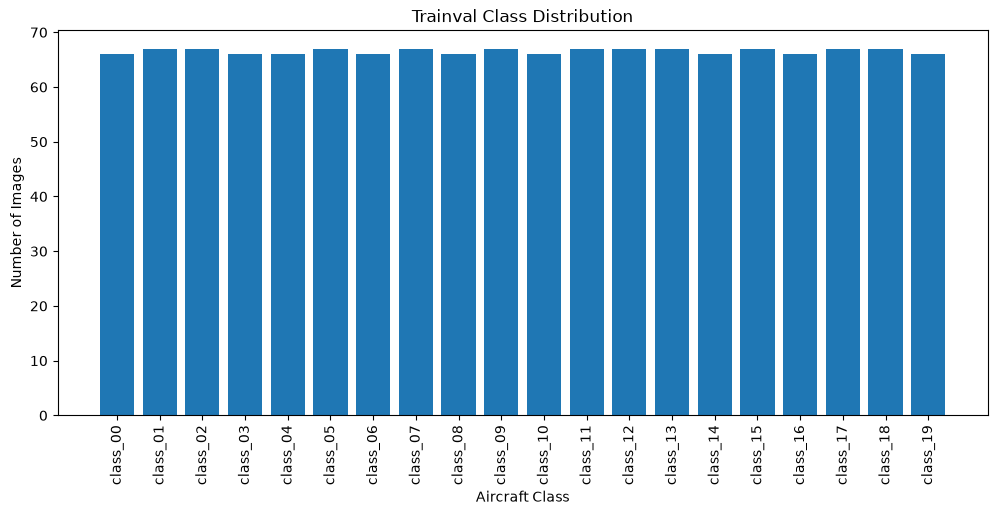

In [8]:
plt.figure(figsize=(12, 5))

plt.bar(
    trainval_distribution['Class'],
    trainval_distribution['Count']
)

plt.xlabel('Aircraft Class')
plt.ylabel('Number of Images')
plt.title('Trainval Class Distribution')
plt.xticks(rotation=90)

plt.show()

### 1.4 Display one example from each class

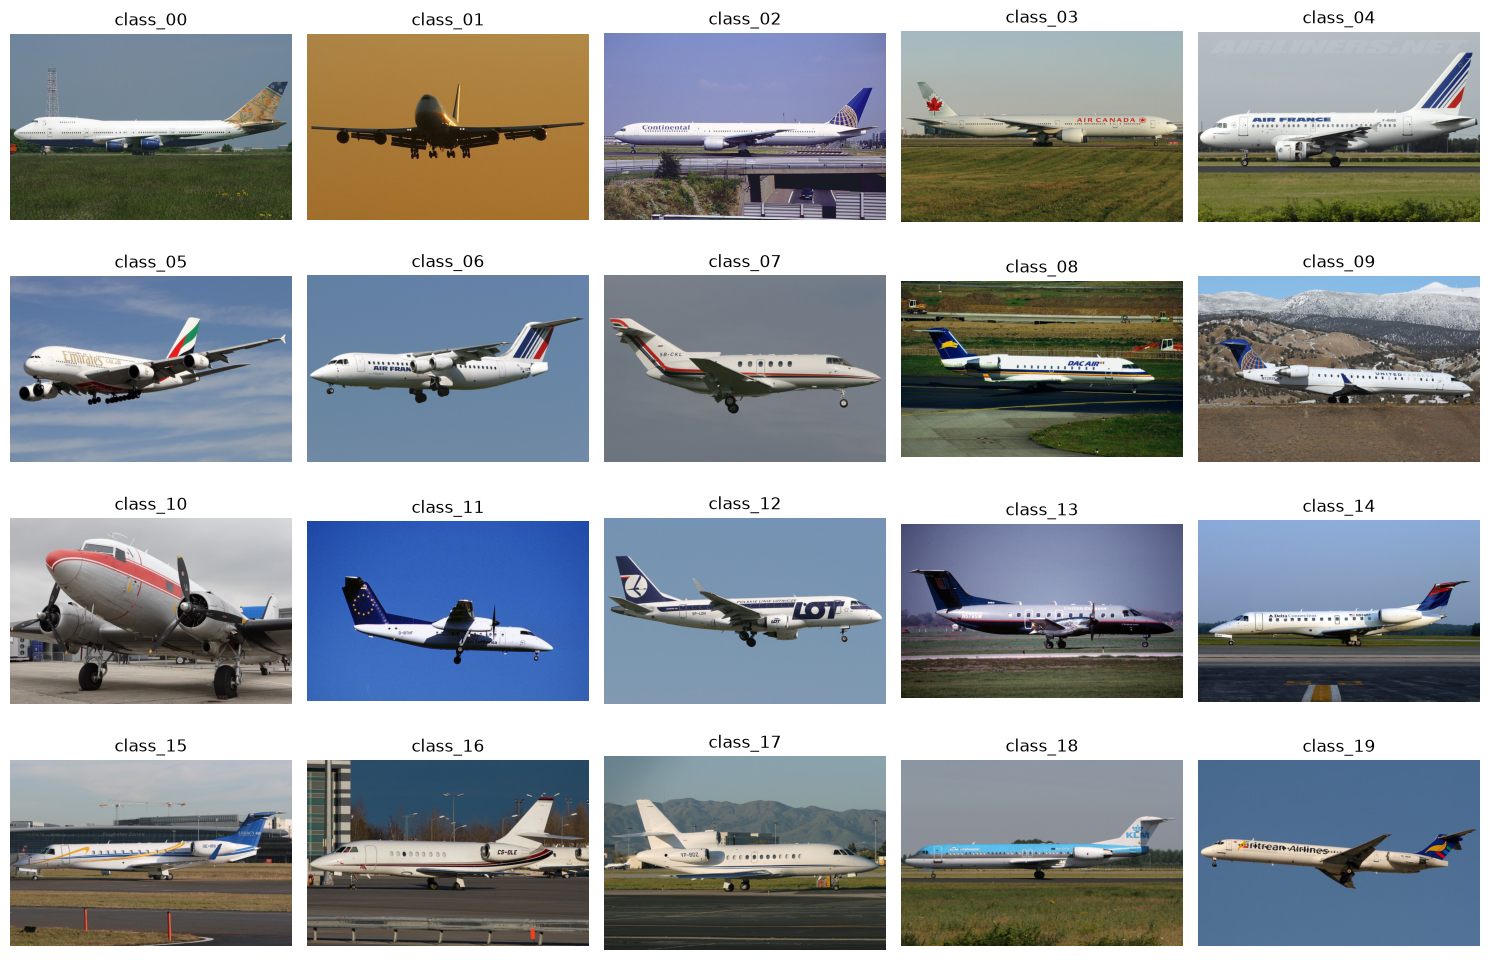

In [9]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(15, 10)
)

axes = axes.flatten()

for class_index, class_name in enumerate(trainval_dataset.classes):

    # Find the first image belonging to this class
    sample_index = trainval_dataset.targets.index(class_index)

    image, label = trainval_dataset[sample_index]

    axes[class_index].imshow(image)
    axes[class_index].set_title(class_name)
    axes[class_index].axis('off')

plt.tight_layout()
plt.show()

### 1.4 Perform the 80/20 stratified split
The task specifically allows an 80/20 split and requires to create your own training and validation subsets from trainval

In [10]:
all_indices = np.arange(
    len(trainval_dataset)
)

all_targets = np.array(
    trainval_dataset.targets
)

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=all_targets,
    random_state=0
)

print(f"Training samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")

Training samples: 1064
Validation samples: 267


#### 1.5 Verify the training/validation class distributions

In [11]:
all_indices = np.arange(
    len(trainval_dataset)
)

all_targets = np.array(
    trainval_dataset.targets
)

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=all_targets,
    random_state=0
)

print(f"Training samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")

Training samples: 1064
Validation samples: 267


Add proportions as an even better checker for class dist

In [12]:
train_targets = all_targets[train_indices]
val_targets = all_targets[val_indices]

train_counts = Counter(train_targets)
val_counts = Counter(val_targets)

split_distribution = pd.DataFrame({
    'Class': trainval_dataset.classes,

    'Trainval': [
        trainval_counts[i]
        for i in range(len(trainval_dataset.classes))
    ],

    'Training': [
        train_counts[i]
        for i in range(len(trainval_dataset.classes))
    ],

    'Validation': [
        val_counts[i]
        for i in range(len(trainval_dataset.classes))
    ]
})

split_distribution

,Class,Trainval,Training,Validation
0,class_00,66,53,13
1,class_01,67,53,14
2,class_02,67,54,13
3,class_03,66,53,13
4,class_04,66,53,13
5,class_05,67,53,14
6,class_06,66,53,13
7,class_07,67,54,13
8,class_08,66,53,13
9,class_09,67,53,14


#### 1.6 Visualise the dist

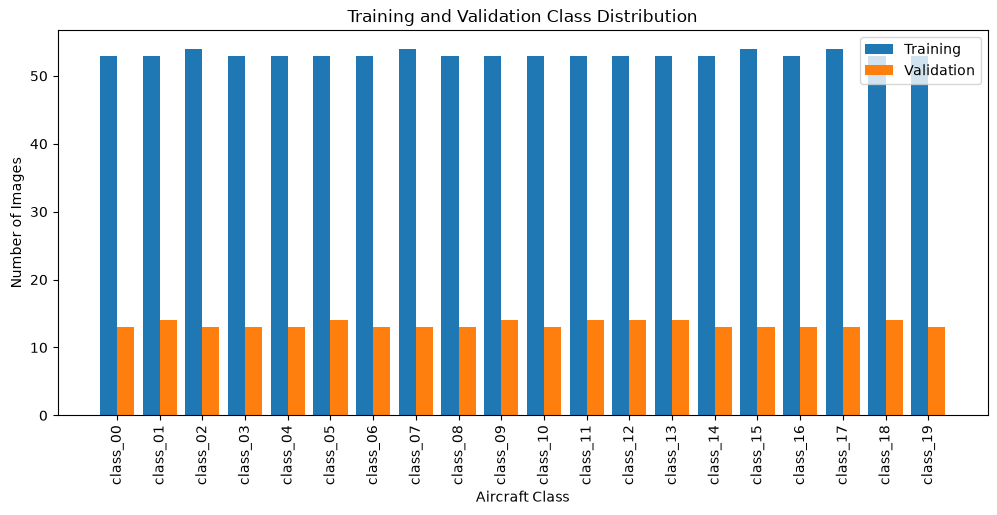

In [13]:
x = np.arange(
    len(trainval_dataset.classes)
)

width = 0.4

plt.figure(figsize=(12, 5))

plt.bar(
    x - width / 2,
    split_distribution['Training'],
    width,
    label='Training'
)

plt.bar(
    x + width / 2,
    split_distribution['Validation'],
    width,
    label='Validation'
)

plt.xlabel('Aircraft Class')
plt.ylabel('Number of Images')
plt.title('Training and Validation Class Distribution')

plt.xticks(
    x,
    trainval_dataset.classes,
    rotation=90
)

plt.legend()

plt.show()

#### final split sanity checks

In [14]:
print(
    "Training/validation overlap:",
    len(set(train_indices).intersection(set(val_indices)))
)

print(
    "Total split samples:",
    len(train_indices) + len(val_indices)
)

print(
    "Original trainval samples:",
    len(trainval_dataset)
)

Training/validation overlap: 0
Total split samples: 1331
Original trainval samples: 1331


In [15]:
print(f"Trainval size: {len(trainval_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Number of classes: {len(trainval_dataset.classes)}")


Trainval size: 1331
Test size: 669
Number of classes: 20


## Part 2: Training the Baseline Model
The baseline uses a pretrained ResNet-18 with the backbone frozen and the final
fully connected layer replaced for the 20 aircraft classes. Only minimal
preprocessing is applied: conversion to tensor, resizing to 224 × 224, and
ImageNet normalisation. No data augmentation is used in the baseline.

In [16]:
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
import tqdm

# ImageNet preprocessing used for pretrained models
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

baseline_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_means, imagenet_stds)
])

In [17]:
# Load separate copies so training and validation can use their own transforms
train_full_dataset = torchvision.datasets.ImageFolder(
    trainval_path,
    transform=baseline_transform
)

val_full_dataset = torchvision.datasets.ImageFolder(
    trainval_path,
    transform=baseline_transform
)

# Apply the existing stratified indices
train_dataset = Subset(train_full_dataset, train_indices)
val_dataset = Subset(val_full_dataset, val_indices)

batch_size = 16

trainloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

valloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Training batches: {len(trainloader)}")
print(f"Validation batches: {len(valloader)}")

Training batches: 67
Validation batches: 17


### 2.1 Baseline Model Training functions
Definitions for:
- setting up the model
    - instatiating the baseline model
- training hyper params (lr, epochs, criterion)
- training and evaluating each epoch

In [18]:
def setup_model(model, num_classes, freeze_backbone=False):
    
    # Adapt the final layer for the new number of classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # Freeze the backbone
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

        #final fully connected layer trainable
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

In [19]:
# Select GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# Load pretrained ResNet-18
backbone = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)

# Replace final layer and freeze the backbone
baseline_model = setup_model(
    backbone,
    num_classes=20,
    freeze_backbone=False
)

baseline_model = baseline_model.to(device)

Device: cuda


In [22]:
# Baseline hyperparameters
lr = 0.001
total_epochs = 15

# Classification loss
criterion = nn.CrossEntropyLoss()

# SGD optimiser
optimizer = optim.SGD(
    baseline_model.parameters(),
    lr=lr,
    momentum=0.9
)

In [23]:
def train_epoch(model, dataloader, criterion, optimizer, epoch, device):

    # Put the model in training mode
    model.train()

    train_loss = []
    correct = 0.0
    total = 0.0

    for _, data in tqdm.tqdm(
        enumerate(dataloader, 0),
        total=len(dataloader),
        desc=f'Epoch {epoch+1} - training phase'
    ):

        # Get inputs and labels and move them to the GPU
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Clear gradients from the previous batch
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss and update model weights
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Store loss and accuracy statistics
        train_loss.append(loss.cpu().item())

        predicted = torch.argmax(outputs, axis=1)

        correct += torch.sum(
            predicted == labels
        ).cpu().item()

        total += len(labels)

    mean_train_loss = np.mean(train_loss)
    train_accuracy = correct / total

    print(
        f"Training {epoch+1}: "
        f"loss={mean_train_loss:.3f} "
        f"acc={train_accuracy:.3f}"
    )

    return mean_train_loss, train_accuracy

In [24]:
def eval_epoch(model, dataloader, criterion, epoch, device):

    # Put the model in evaluation mode
    model.eval()

    val_loss = 0.0
    val_correct = 0.0
    val_total = 0.0

    # No gradients are required during validation
    with torch.no_grad():

        for _, data in tqdm.tqdm(
            enumerate(dataloader, 0),
            total=len(dataloader),
            desc=f'Epoch {epoch+1} - validation phase'
        ):

            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)

            predicted = torch.argmax(
                outputs,
                axis=1
            )

            # Calculate validation loss
            loss = criterion(outputs, labels)

            val_loss += (
                loss.cpu().item()
                * inputs.size(0)
            )

            val_correct += torch.sum(
                predicted == labels
            ).cpu().item()

            val_total += inputs.size(0)

    mean_val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total

    print(
        f"Validation {epoch+1}: "
        f"loss={mean_val_loss:.3f} "
        f"acc={val_accuracy:.3f}"
    )

    return mean_val_loss, val_accuracy

### 2.2 Training the Baseline model

In [25]:
baseline_train_loss = []
baseline_val_loss = []

baseline_train_acc = []
baseline_val_acc = []

best_acc = -np.inf

for epoch in range(total_epochs):

    # Train for one epoch
    mean_train_loss, train_accuracy = train_epoch(
        baseline_model,
        trainloader,
        criterion,
        optimizer,
        epoch,
        device
    )

    baseline_train_loss.append(mean_train_loss)
    baseline_train_acc.append(train_accuracy)

    # Evaluate on validation set
    mean_val_loss, val_accuracy = eval_epoch(
        baseline_model,
        valloader,
        criterion,
        epoch,
        device
    )

    baseline_val_loss.append(mean_val_loss)
    baseline_val_acc.append(val_accuracy)

    # Save the model with the best validation accuracy
    if val_accuracy > best_acc:

        torch.save(
            baseline_model.state_dict(),
            "baseline_resnet18_best.pth"
        )

        best_acc = val_accuracy

        print(
            f"Best model found at epoch {epoch+1} "
            f"with validation accuracy {best_acc:.3f}"
        )

Epoch 1 - training phase: 100%|██████████| 67/67 [00:15<00:00,  4.39it/s]


Training 1: loss=2.796 acc=0.180


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.06it/s]


Validation 1: loss=2.293 acc=0.378
Best model found at epoch 1 with validation accuracy 0.378


Epoch 2 - training phase: 100%|██████████| 67/67 [00:13<00:00,  4.83it/s]


...

Validation 14: loss=0.682 acc=0.801


Epoch 15 - training phase: 100%|██████████| 67/67 [00:14<00:00,  4.77it/s]


Training 15: loss=0.023 acc=1.000


Epoch 15 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.32it/s]

Validation 15: loss=0.682 acc=0.798


### 2.3 Summarising Baseline Performance

In [26]:
# Summarise baseline performance
baseline_best_epoch = np.argmax(baseline_val_acc) + 1
baseline_best_val_acc = np.max(baseline_val_acc)

print(f"Best validation accuracy: {baseline_best_val_acc:.3f}")
print(f"Best epoch: {baseline_best_epoch}")

Best validation accuracy: 0.805
Best epoch: 10


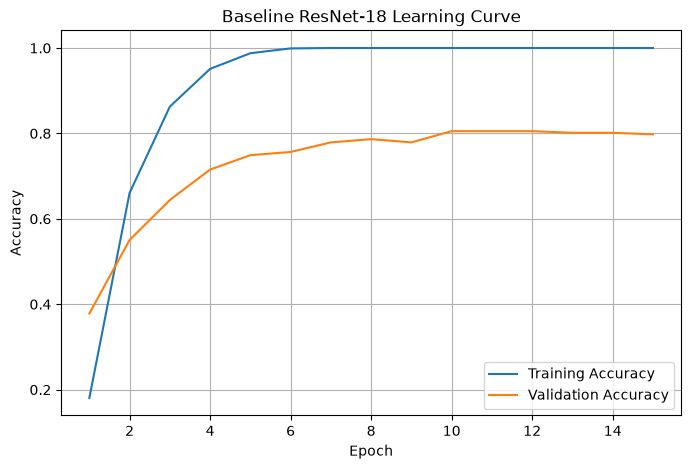

In [27]:
epochs = np.arange(1, total_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    baseline_train_acc,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    baseline_val_acc,
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline ResNet-18 Learning Curve')
plt.legend()
plt.grid()

plt.show()

In [28]:
np.savez(
    'baseline_history.npz',
    train_loss=np.array(baseline_train_loss),
    val_loss=np.array(baseline_val_loss),
    train_acc=np.array(baseline_train_acc),
    val_acc=np.array(baseline_val_acc)
)

## Part 3 - Experiments

## 3.1 Experiment 1 - Data Augmentation

### Hypothesis

Adding data augmentation to the training images may improve validation
performance by increasing the variation in the training data and reducing
overfitting.

The model architecture, optimiser, learning rate, batch size, number of
epochs, and train/validation split remain unchanged from the baseline.
Only the training data augmentation strategy is changed.

In [29]:
experiment1_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_means, imagenet_stds)
])

In [30]:
# Training dataset with augmentation
experiment1_train_full = torchvision.datasets.ImageFolder(
    trainval_path,
    transform=experiment1_train_transform
)

# Validation dataset uses exactly the baseline preprocessing
experiment1_val_full = torchvision.datasets.ImageFolder(
    trainval_path,
    transform=baseline_transform
)

experiment1_train_dataset = Subset(
    experiment1_train_full,
    train_indices
)

experiment1_val_dataset = Subset(
    experiment1_val_full,
    val_indices
)

In [31]:
experiment1_trainloader = DataLoader(
    experiment1_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

experiment1_valloader = DataLoader(
    experiment1_val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print(f"Training batches: {len(experiment1_trainloader)}")
print(f"Validation batches: {len(experiment1_valloader)}")

Training batches: 67
Validation batches: 17


In [32]:
torch.manual_seed(0)
np.random.seed(0)

backbone = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)

experiment1_model = setup_model(
    backbone,
    num_classes=20,
    freeze_backbone=False
)

experiment1_model = experiment1_model.to(device)

In [33]:
experiment1_criterion = nn.CrossEntropyLoss()

experiment1_optimizer = optim.SGD(
    experiment1_model.parameters(),
    lr=0.001,
    momentum=0.9
)

experiment1_epochs = 15

In [34]:
experiment1_train_loss = []
experiment1_val_loss = []

experiment1_train_acc = []
experiment1_val_acc = []

experiment1_best_acc = -np.inf

for epoch in range(experiment1_epochs):

    mean_train_loss, train_accuracy = train_epoch(
        experiment1_model,
        experiment1_trainloader,
        experiment1_criterion,
        experiment1_optimizer,
        epoch,
        device
    )

    experiment1_train_loss.append(mean_train_loss)
    experiment1_train_acc.append(train_accuracy)

    mean_val_loss, val_accuracy = eval_epoch(
        experiment1_model,
        experiment1_valloader,
        experiment1_criterion,
        epoch,
        device
    )

    experiment1_val_loss.append(mean_val_loss)
    experiment1_val_acc.append(val_accuracy)

    if val_accuracy > experiment1_best_acc:

        torch.save(
            experiment1_model.state_dict(),
            "experiment1_augmentation_best.pth"
        )

        experiment1_best_acc = val_accuracy

        print(
            f"Best model found at epoch {epoch+1} "
            f"with validation accuracy {experiment1_best_acc:.3f}"
        )

Epoch 1 - training phase: 100%|██████████| 67/67 [00:47<00:00,  1.41it/s]


Training 1: loss=2.897 acc=0.129


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  5.88it/s]


Validation 1: loss=2.564 acc=0.232
Best model found at epoch 1 with validation accuracy 0.232


Epoch 2 - training phase: 100%|██████████| 67/67 [00:46<00:00,  1.43it/s]


...

Validation 14: loss=0.493 acc=0.850
Best model found at epoch 14 with validation accuracy 0.850


Epoch 15 - training phase: 100%|██████████| 67/67 [00:47<00:00,  1.40it/s]


Training 15: loss=0.104 acc=0.987


Epoch 15 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  5.78it/s]

Validation 15: loss=0.492 acc=0.846


In [35]:
experiment1_best_epoch = np.argmax(experiment1_val_acc) + 1
experiment1_best_val_acc = np.max(experiment1_val_acc)

print(f"Best validation accuracy: {experiment1_best_val_acc:.3f}")
print(f"Best epoch: {experiment1_best_epoch}")

Best validation accuracy: 0.850
Best epoch: 14


In [36]:
np.savez(
    'experiment1_history.npz',
    train_loss=np.array(experiment1_train_loss),
    val_loss=np.array(experiment1_val_loss),
    train_acc=np.array(experiment1_train_acc),
    val_acc=np.array(experiment1_val_acc)
)

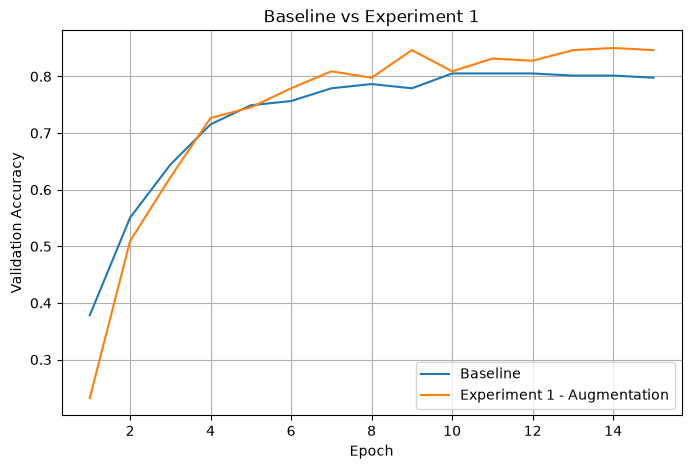

In [39]:
epochs = np.arange(1, len(baseline_val_acc) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    baseline_val_acc,
    label='Baseline'
)

plt.plot(
    epochs,
    experiment1_val_acc,
    label='Experiment 1 - Augmentation'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Baseline vs Experiment 1')
plt.legend()
plt.grid()

plt.show()

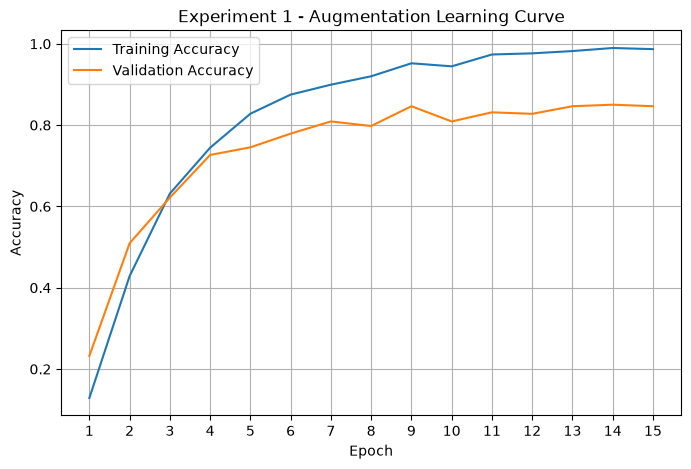

In [40]:
# Experiment 1 training and validation accuracy convergence

epochs = np.arange(1, experiment1_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    experiment1_train_acc,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    experiment1_val_acc,
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 1 - Augmentation Learning Curve')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.show()

## 3.2 Experiment 2 - Learning Rate Optimisation with Optuna

### Hypothesis

Optimising the learning rate using Optuna may identify a learning rate that
allows the frozen ResNet-18 classification layer to converge more effectively
and achieve higher validation accuracy than the baseline learning rate of
0.001.

Only the learning rate is varied. The model architecture, preprocessing,
optimiser, momentum, batch size, number of epochs, and train/validation split
remain unchanged from the baseline.

In [41]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [optuna]2m1/2 [optuna]


In [42]:
import optuna

In [43]:
def objective(trial):

    # Only hyperparameter being changed
    lr = trial.suggest_float(
        "lr",
        1e-4,
        1e-2,
        log=True
    )

    # Reset seeds so trials start consistently
    torch.manual_seed(0)
    np.random.seed(0)

    # Fresh pretrained ResNet-18 for every trial
    backbone = torchvision.models.resnet18(
        weights=torchvision.models.ResNet18_Weights.DEFAULT
    )

    model = setup_model(
        backbone,
        num_classes=20,
        freeze_backbone=False
    )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    best_val_acc = -np.inf

    for epoch in range(15):

        train_epoch(
            model,
            trainloader,
            criterion,
            optimizer,
            epoch,
            device
        )

        _, val_accuracy = eval_epoch(
            model,
            valloader,
            criterion,
            epoch,
            device
        )

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy

    return best_val_acc

In [44]:
study = optuna.create_study(
    study_name="experiment2_learning_rate",
    direction="maximize",
    storage="sqlite:///experiment2_optuna.db",
    load_if_exists=True
)

study.optimize(
    objective,
    n_trials=10
)

[I 2026-08-23 04:37:52,246] Using an existing study with name 'experiment2_learning_rate' instead of creating a new one.
Epoch 1 - training phase: 100%|██████████| 67/67 [00:15<00:00,  4.30it/s]


Training 1: loss=2.185 acc=0.322


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:03<00:00,  5.36it/s]


Validation 1: loss=1.780 acc=0.453


Epoch 2 - training phase: 100%|██████████| 67/67 [00:14<00:00,  4.69it/s]


...

Validation 14: loss=0.683 acc=0.801


Epoch 15 - training phase: 100%|██████████| 67/67 [00:15<00:00,  4.41it/s]


Training 15: loss=0.024 acc=1.000


Epoch 15 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  5.83it/s]
[I 2026-08-23 05:23:27,808] Trial 19 finished with value: 0.8089887640449438 and parameters: {'lr': 0.0009925506382605148}. Best is trial 16 with value: 0.8801498127340824.


Validation 15: loss=0.684 acc=0.794


In [45]:
print("Best learning rate:", study.best_params["lr"])
print("Best validation accuracy:", study.best_value)

Best learning rate: 0.004088922624251132
Best validation accuracy: 0.8801498127340824


In [46]:
# Best learning rate selected by Optuna
experiment2_best_lr = study.best_params["lr"]

print("Selected learning rate:", experiment2_best_lr)

Selected learning rate: 0.004088922624251132


In [47]:
torch.manual_seed(0)
np.random.seed(0)

experiment2_backbone = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)

experiment2_model = setup_model(
    experiment2_backbone,
    num_classes=20,
    freeze_backbone=False
)

experiment2_model = experiment2_model.to(device)

experiment2_criterion = nn.CrossEntropyLoss()

experiment2_optimizer = optim.SGD(
    experiment2_model.parameters(),
    lr=experiment2_best_lr,
    momentum=0.9
)

experiment2_epochs = 15

In [48]:
experiment2_train_loss = []
experiment2_val_loss = []

experiment2_train_acc = []
experiment2_val_acc = []

experiment2_best_acc = -np.inf

for epoch in range(experiment2_epochs):

    mean_train_loss, train_accuracy = train_epoch(
        experiment2_model,
        trainloader,
        experiment2_criterion,
        experiment2_optimizer,
        epoch,
        device
    )

    experiment2_train_loss.append(mean_train_loss)
    experiment2_train_acc.append(train_accuracy)

    mean_val_loss, val_accuracy = eval_epoch(
        experiment2_model,
        valloader,
        experiment2_criterion,
        epoch,
        device
    )

    experiment2_val_loss.append(mean_val_loss)
    experiment2_val_acc.append(val_accuracy)

    if val_accuracy > experiment2_best_acc:

        torch.save(
            experiment2_model.state_dict(),
            "experiment2_lr_best.pth"
        )

        experiment2_best_acc = val_accuracy

        print(
            f"Best model found at epoch {epoch+1} "
            f"with validation accuracy {experiment2_best_acc:.3f}"
        )

Epoch 1 - training phase: 100%|██████████| 67/67 [00:15<00:00,  4.37it/s]


Training 1: loss=2.291 acc=0.303


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:03<00:00,  5.55it/s]


Validation 1: loss=1.400 acc=0.536
Best model found at epoch 1 with validation accuracy 0.536


Epoch 2 - training phase: 100%|██████████| 67/67 [00:14<00:00,  4.65it/s]


...

Validation 14: loss=0.525 acc=0.835
Best model found at epoch 14 with validation accuracy 0.835


Epoch 15 - training phase: 100%|██████████| 67/67 [00:14<00:00,  4.56it/s]


Training 15: loss=0.003 acc=1.000


Epoch 15 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  5.69it/s]

Validation 15: loss=0.514 acc=0.835


In [49]:
experiment2_best_epoch = np.argmax(experiment2_val_acc) + 1
experiment2_best_val_acc = np.max(experiment2_val_acc)

print(f"Best learning rate: {experiment2_best_lr}")
print(f"Best validation accuracy: {experiment2_best_val_acc:.3f}")
print(f"Best epoch: {experiment2_best_epoch}")

Best learning rate: 0.004088922624251132
Best validation accuracy: 0.835
Best epoch: 14


In [50]:
np.savez(
    'experiment2_history.npz',
    train_loss=np.array(experiment2_train_loss),
    val_loss=np.array(experiment2_val_loss),
    train_acc=np.array(experiment2_train_acc),
    val_acc=np.array(experiment2_val_acc)
)

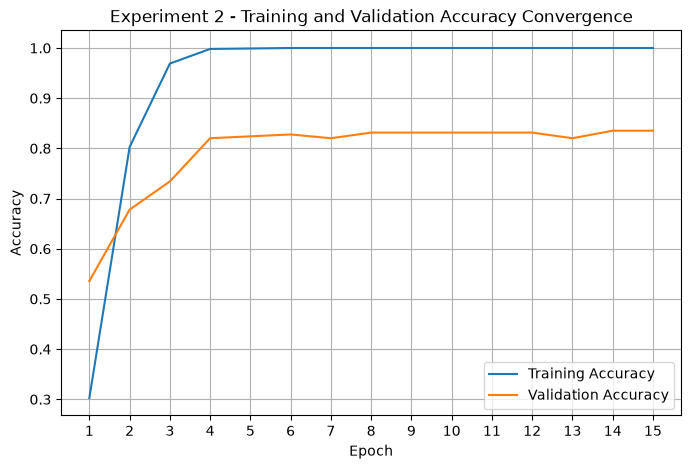

In [51]:
epochs = np.arange(1, experiment2_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    experiment2_train_acc,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    experiment2_val_acc,
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 2 - Training and Validation Accuracy Convergence')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.show()

## 3.3 Experiment 3 - EfficientNet Architecture

### Hypothesis

Replacing the ResNet-18 backbone with EfficientNet-B0 may improve validation
accuracy because a different feature extraction architecture may learn more
useful representations for fine-grained aircraft classification.

Only the neural network architecture is changed. The preprocessing,
train/validation split, batch size, optimiser, learning rate, momentum,
number of epochs, and fine-tuning strategy remain unchanged from the baseline.

In [52]:
def setup_efficientnet(model, num_classes, freeze_backbone=False):

    # Replace the final classification layer
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(
        in_features,
        num_classes
    )

    # Freeze the feature-extraction backbone
    if freeze_backbone:

        for param in model.parameters():
            param.requires_grad = False

        # Keep the classifier trainable
        for param in model.classifier.parameters():
            param.requires_grad = True

    return model

In [53]:
torch.manual_seed(0)
np.random.seed(0)

experiment3_backbone = torchvision.models.efficientnet_b0(
    weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
)

experiment3_model = setup_efficientnet(
    experiment3_backbone,
    num_classes=20,
    freeze_backbone=False
)

experiment3_model = experiment3_model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /tmp/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 356MB/s]


In [54]:
experiment3_criterion = nn.CrossEntropyLoss()

experiment3_optimizer = optim.SGD(
    experiment3_model.parameters(),
    lr=0.001,
    momentum=0.9
)

experiment3_epochs = 15

In [55]:
trainloader
valloader

In [56]:
experiment3_train_loss = []
experiment3_val_loss = []

experiment3_train_acc = []
experiment3_val_acc = []

experiment3_best_acc = -np.inf

for epoch in range(experiment3_epochs):

    mean_train_loss, train_accuracy = train_epoch(
        experiment3_model,
        trainloader,
        experiment3_criterion,
        experiment3_optimizer,
        epoch,
        device
    )

    experiment3_train_loss.append(mean_train_loss)
    experiment3_train_acc.append(train_accuracy)

    mean_val_loss, val_accuracy = eval_epoch(
        experiment3_model,
        valloader,
        experiment3_criterion,
        epoch,
        device
    )

    experiment3_val_loss.append(mean_val_loss)
    experiment3_val_acc.append(val_accuracy)

    if val_accuracy > experiment3_best_acc:

        torch.save(
            experiment3_model.state_dict(),
            "experiment3_efficientnet_best.pth"
        )

        experiment3_best_acc = val_accuracy

        print(
            f"Best model found at epoch {epoch+1} "
            f"with validation accuracy {experiment3_best_acc:.3f}"
        )

Epoch 1 - training phase: 100%|██████████| 67/67 [00:21<00:00,  3.07it/s]


Training 1: loss=2.954 acc=0.107


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:04<00:00,  3.87it/s]


Validation 1: loss=2.857 acc=0.213
Best model found at epoch 1 with validation accuracy 0.213


Epoch 2 - training phase: 100%|██████████| 67/67 [00:20<00:00,  3.20it/s]


...

Validation 14: loss=0.699 acc=0.794
Best model found at epoch 14 with validation accuracy 0.794


Epoch 15 - training phase: 100%|██████████| 67/67 [00:18<00:00,  3.71it/s]


Training 15: loss=0.273 acc=0.963


Epoch 15 - validation phase: 100%|██████████| 17/17 [00:03<00:00,  5.64it/s]

Validation 15: loss=0.695 acc=0.775


In [57]:
experiment3_best_epoch = np.argmax(experiment3_val_acc) + 1
experiment3_best_val_acc = np.max(experiment3_val_acc)

print(f"Best validation accuracy: {experiment3_best_val_acc:.3f}")
print(f"Best epoch: {experiment3_best_epoch}")

Best validation accuracy: 0.794
Best epoch: 14


In [58]:
np.savez(
    'experiment3_history.npz',
    train_loss=np.array(experiment3_train_loss),
    val_loss=np.array(experiment3_val_loss),
    train_acc=np.array(experiment3_train_acc),
    val_acc=np.array(experiment3_val_acc)
)

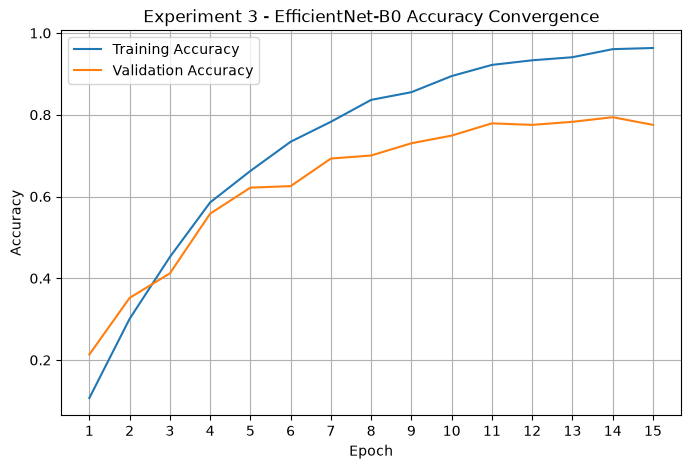

In [59]:
epochs = np.arange(1, experiment3_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    experiment3_train_acc,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    experiment3_val_acc,
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 3 - EfficientNet-B0 Accuracy Convergence')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.show()

## 3.4 - Experiment 1, 2 & 3 Validation Accuracy Comparison

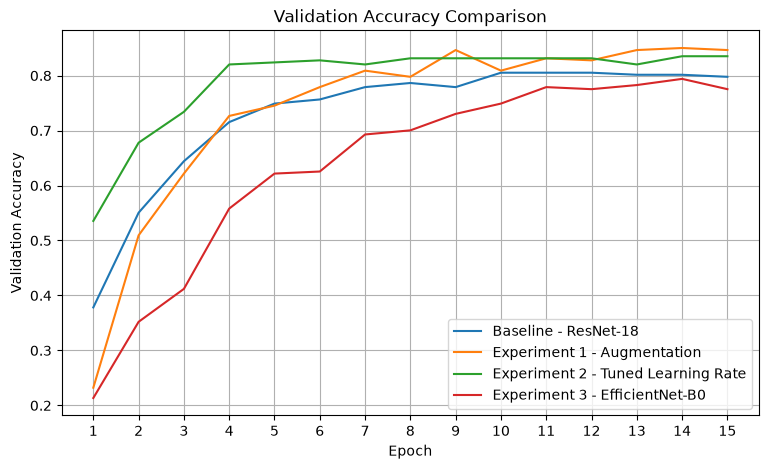

In [61]:
epochs = np.arange(1, len(baseline_val_acc) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    baseline_val_acc,
    label='Baseline - ResNet-18'
)

plt.plot(
    epochs,
    experiment1_val_acc,
    label='Experiment 1 - Augmentation'
)

plt.plot(
    epochs,
    experiment2_val_acc,
    label='Experiment 2 - Tuned Learning Rate'
)

plt.plot(
    epochs,
    experiment3_val_acc,
    label='Experiment 3 - EfficientNet-B0'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.show()

From the above, we can see that experiment 2 was the best performing across all epochs, and notably, was the only of the experiements to out perform the baseline models validation accuracy. All were trained on 15 epochs.

In [62]:
print(f"Experiment 2 best validation accuracy: {experiment2_best_val_acc:.3f}")
print(f"Experiment 2 best epoch: {experiment2_best_epoch}")
print(f"Selected learning rate: {experiment2_best_lr}")

Experiment 2 best validation accuracy: 0.835
Experiment 2 best epoch: 14
Selected learning rate: 0.004088922624251132


### 3.4.2 Best Model from Controlled Experiments

The final model uses the ResNet-18 architecture from the baseline with the
augmented data from Experiment 2.

While Optuna did show slight improvement over baseline, and combining this with the augmented
data could potentially cause improvement, the processing cost is expensive and doesn't appear to
cause a significant enough improvement to validate the cost.

The final model is retrained using the complete trainval dataset before being
evaluated once on the held-out test set.

In [64]:
final_train_dataset = torchvision.datasets.ImageFolder(
    trainval_path,
    transform=experiment1_train_transform
)

final_trainloader = DataLoader(
    final_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

print(f"Final training samples: {len(final_train_dataset)}")
print(f"Final training batches: {len(final_trainloader)}")

Final training samples: 1331
Final training batches: 84


In [66]:
# Reset seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Fresh pretrained ResNet-18
final_backbone = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)

# Match Experiment 1: fully unfrozen
final_model = setup_model(
    final_backbone,
    num_classes=20,
    freeze_backbone=False
)

final_model = final_model.to(device)

# Same loss and optimiser as Experiment 1
final_criterion = nn.CrossEntropyLoss()

final_optimizer = optim.SGD(
    final_model.parameters(),
    lr=0.001,
    momentum=0.9
)

# Epoch selected from Experiment 1 validation performance
final_epochs = experiment1_best_epoch

print(f"Final learning rate: 0.001")
print(f"Final training epochs: {final_epochs}")

Final learning rate: 0.001
Final training epochs: 14


In [67]:
final_train_loss = []
final_train_acc = []

for epoch in range(final_epochs):

    mean_train_loss, train_accuracy = train_epoch(
        final_model,
        final_trainloader,
        final_criterion,
        final_optimizer,
        epoch,
        device
    )

    final_train_loss.append(mean_train_loss)
    final_train_acc.append(train_accuracy)

# Save final trained model
torch.save(
    final_model.state_dict(),
    "final_winning_model.pth"
)

print("Final winning model saved.")

Epoch 1 - training phase: 100%|██████████| 84/84 [01:00<00:00,  1.38it/s]


Training 1: loss=2.819 acc=0.146


Epoch 2 - training phase: 100%|██████████| 84/84 [01:00<00:00,  1.38it/s]


Training 2: loss=1.918 acc=0.461


Epoch 3 - training phase: 100%|██████████| 84/84 [01:00<00:00,  1.38it/s]


...

Training 12: loss=0.148 acc=0.976


Epoch 13 - training phase: 100%|██████████| 84/84 [01:00<00:00,  1.38it/s]


Training 13: loss=0.125 acc=0.975


Epoch 14 - training phase: 100%|██████████| 84/84 [01:01<00:00,  1.37it/s]


Training 14: loss=0.097 acc=0.989
Final winning model saved.


In [68]:
experiment1_best_epoch = np.argmax(experiment1_val_acc) + 1
experiment1_best_val_acc = np.max(experiment1_val_acc)

print(f"Best Experiment 1 validation accuracy: {experiment1_best_val_acc:.3f}")
print(f"Best epoch: {experiment1_best_epoch}")

Best Experiment 1 validation accuracy: 0.850
Best epoch: 14


In [69]:
np.savez(
    'final_model_history.npz',
    train_loss=np.array(final_train_loss),
    train_acc=np.array(final_train_acc)
)

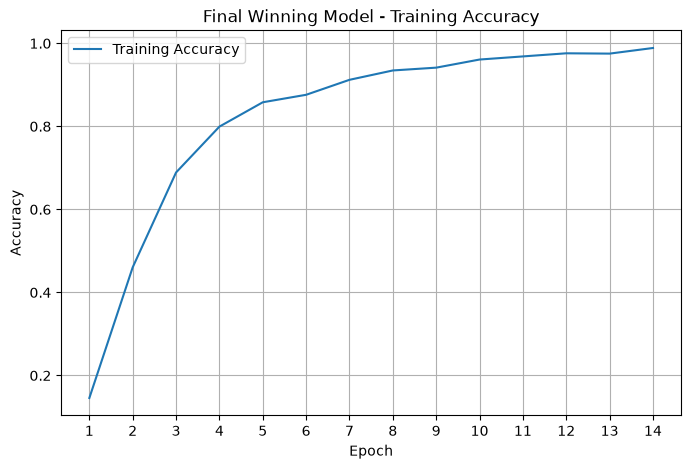

In [70]:
epochs = np.arange(1, len(final_train_acc) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    final_train_acc,
    label='Training Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Final Winning Model - Training Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.show()

In [71]:
test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=baseline_transform
)

testloader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print(f"Test samples: {len(test_dataset)}")
print(f"Test batches: {len(testloader)}")

Test samples: 669
Test batches: 42


In [72]:
final_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in testloader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = final_model(inputs)

        predicted = torch.argmax(
            outputs,
            axis=1
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

In [73]:
num_classes = 20

class_accuracies = []

for class_idx in range(num_classes):

    class_mask = all_labels == class_idx

    class_accuracy = (
        all_predictions[class_mask]
        == all_labels[class_mask]
    ).sum() / float(class_mask.sum())

    class_accuracies.append(class_accuracy)

In [74]:
average_per_class_accuracy = np.mean(class_accuracies)

print(
    f"Average per-class test accuracy: "
    f"{average_per_class_accuracy:.3f}"
)

Average per-class test accuracy: 0.873


In [76]:
class_names = test_dataset.classes

for class_name, accuracy in zip(
    class_names,
    class_accuracies
):
    print(f"{class_name}: {accuracy:.3f}")

class_00: 0.500
class_01: 0.758
class_02: 0.879
class_03: 0.912
class_04: 0.941
class_05: 0.758
class_06: 0.912
class_07: 0.909
class_08: 0.824
class_09: 0.939
class_10: 0.941
class_11: 1.000
class_12: 0.939
class_13: 0.970
class_14: 0.912
class_15: 0.848
class_16: 1.000
class_17: 0.939
class_18: 0.788
class_19: 0.794


In [77]:
np.savez(
    "winning_model_test_results.npz",
    class_accuracies=np.array(class_accuracies),
    average_per_class_accuracy=average_per_class_accuracy,
    predictions=all_predictions,
    labels=all_labels
)

print("Final test results saved.")

Final test results saved.


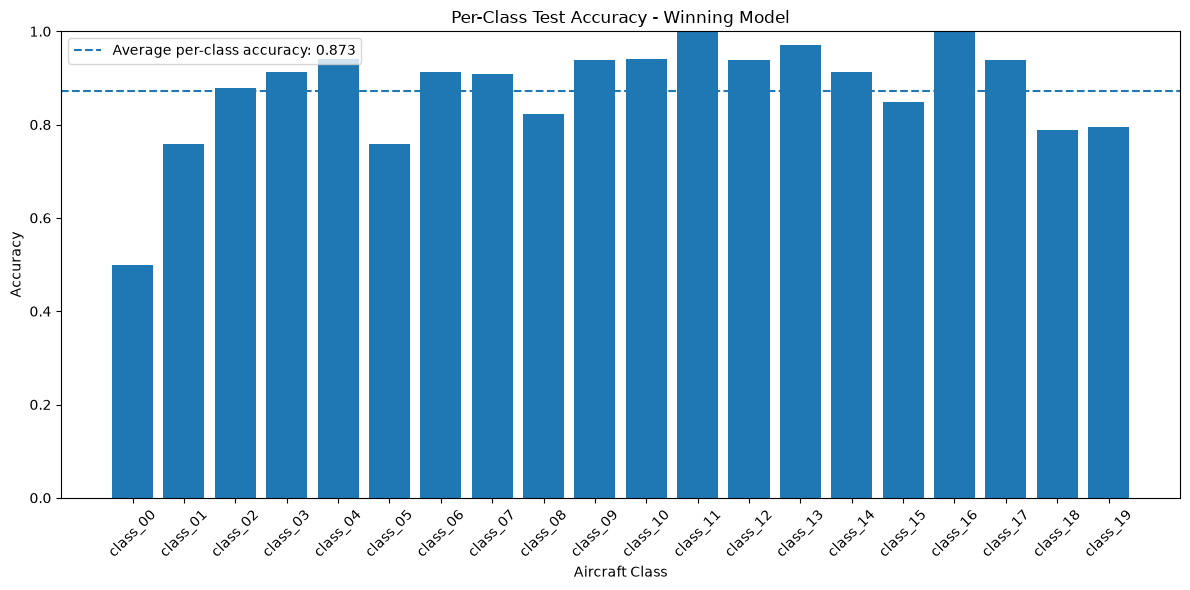

In [78]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_names,
    class_accuracies
)

plt.axhline(
    y=average_per_class_accuracy,
    linestyle='--',
    label=f'Average per-class accuracy: {average_per_class_accuracy:.3f}'
)

plt.xlabel('Aircraft Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Test Accuracy - Winning Model')

plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.show()

## Part 5 - Model Comparison

The baseline and three required controlled experiments are compared first. An additional full fine-tuning refinement is included because it was evaluated on the same validation split and ultimately produced the strongest validation performance.

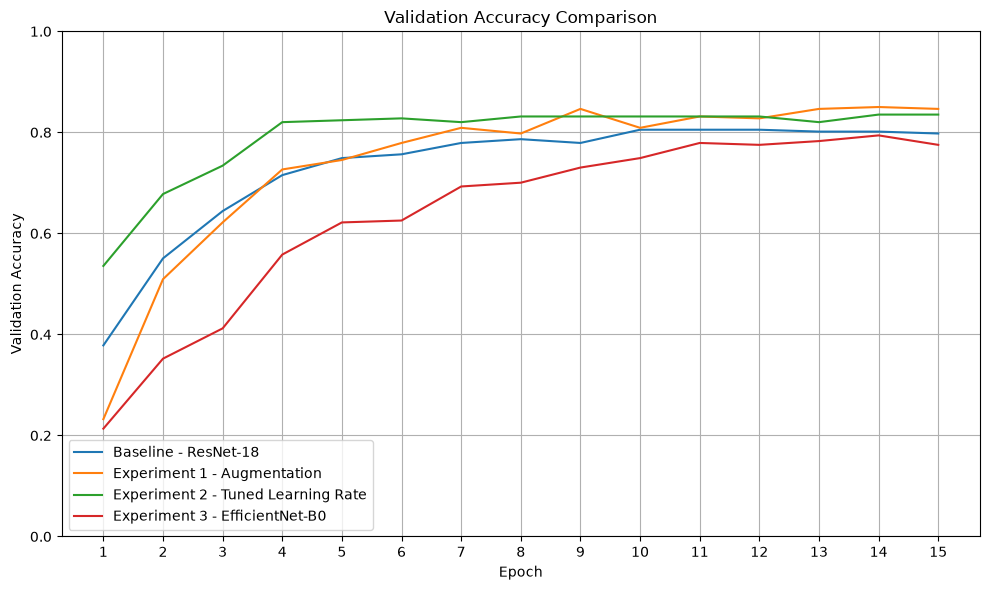

In [79]:
epochs = np.arange(1, len(baseline_val_acc) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_val_acc,
    label='Baseline - ResNet-18'
)

plt.plot(
    epochs,
    experiment1_val_acc,
    label='Experiment 1 - Augmentation'
)

plt.plot(
    epochs,
    experiment2_val_acc,
    label='Experiment 2 - Tuned Learning Rate'
)

plt.plot(
    epochs,
    experiment3_val_acc,
    label='Experiment 3 - EfficientNet-B0'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xticks(epochs)
plt.ylim(0, 1)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [80]:
results_table = pd.DataFrame({
    'Model': [
        'Baseline',
        'Experiment 1 - Augmentation',
        'Experiment 2 - Tuned LR',
        'Experiment 3 - EfficientNet-B0'
    ],
    'Best Validation Accuracy': [
        np.max(baseline_val_acc),
        np.max(experiment1_val_acc),
        np.max(experiment2_val_acc),
        np.max(experiment3_val_acc)
    ]
})

results_table

,Model,Best Validation Accuracy
0,Baseline,0.805243
1,Experiment 1 - Augmentation,0.850187
2,Experiment 2 - Tuned LR,0.835206
3,Experiment 3 - EfficientNet-B0,0.794007
